In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"Tabela_Populacao_2010_2022.xlsx"

df = pd.read_excel(path, sheet_name="Municípios", header=2, usecols="B:H")
df = df.iloc[:5570].reset_index(drop=True)

df = df.rename(columns={
    "COD. UF": "cod_uf",
    "UF": "uf",
    "COD. MUNIC": "cod_munic",
    "NOME DO MUNICÍPIO": "municipio",
    "População Município 2010\n(Sinopse)": "pop_2010_sinopse",
    "População 2010 (Alterações de Limites até 2022)1": "pop_2010",
    "População Censo 2022": "pop_2022",
})

col_2010 = "pop_2010"
col_2022 = "pop_2022"

df.head()

,uf,cod_uf,cod_munic,municipio,pop_2010_sinopse,pop_2010,pop_2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


In [3]:
pop_estado = (
    df.groupby(["cod_uf", "uf"], as_index=False)
    .agg(
        populacao_2010=(col_2010, "sum"),
        populacao_2022=(col_2022, "sum"),
    )
)

pop_estado

,cod_uf,uf,populacao_2010,populacao_2022
0,11.0,RO,1562409.0,1581196.0
1,12.0,AC,733559.0,830018.0
2,13.0,AM,3483985.0,3941613.0
3,14.0,RR,450479.0,636707.0
4,15.0,PA,7581051.0,8120131.0
5,16.0,AP,669526.0,733759.0
6,17.0,TO,1383445.0,1511460.0
7,21.0,MA,6574789.0,6776699.0
8,22.0,PI,3119097.0,3271199.0
9,23.0,CE,8451644.0,8794957.0


In [4]:
pop_estado["crescimento_abs"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado["crescimento_pct"] = (pop_estado["crescimento_abs"] / pop_estado["populacao_2010"]) * 100

pop_estado = pop_estado.sort_values("crescimento_abs", ascending=False).reset_index(drop=True)
pop_estado

,cod_uf,uf,populacao_2010,populacao_2022,crescimento_abs,crescimento_pct
0,35.0,SP,41262199.0,44411238.0,3149039.0,7.631777
1,42.0,SC,6248436.0,7610361.0,1361925.0,21.796254
2,52.0,GO,6001789.0,7056495.0,1054706.0,17.573194
3,41.0,PR,10444526.0,11444380.0,999854.0,9.572995
4,31.0,MG,19597330.0,20539989.0,942659.0,4.810140
5,51.0,MT,3035122.0,3658649.0,623527.0,20.543721
6,15.0,PA,7581051.0,8120131.0,539080.0,7.110887
7,13.0,AM,3483985.0,3941613.0,457628.0,13.135189
8,23.0,CE,8451644.0,8794957.0,343313.0,4.062085
9,32.0,ES,3514952.0,3833712.0,318760.0,9.068687


In [5]:
pop_estado.to_csv(r"pop_por_estado.csv", sep=";", index=False, decimal=",")

In [6]:
pop_municipio = df[["cod_uf", "uf", "cod_munic", "municipio", col_2010, col_2022]].copy()
pop_municipio = pop_municipio.rename(columns={col_2010: "populacao_2010", col_2022: "populacao_2022"})
pop_municipio

,cod_uf,uf,cod_munic,municipio,populacao_2010,populacao_2022
0,11.0,RO,15.0,Alta Floresta D'Oeste,24392.0,21494.0
1,11.0,RO,23.0,Ariquemes,90353.0,96833.0
2,11.0,RO,31.0,Cabixi,6313.0,5351.0
3,11.0,RO,49.0,Cacoal,78574.0,86887.0
4,11.0,RO,56.0,Cerejeiras,17029.0,15890.0
...,...,...,...,...,...,...
5565,52.0,GO,22005.0,Vianópolis,12548.0,14956.0
5566,52.0,GO,22054.0,Vicentinópolis,7373.0,8768.0
5567,52.0,GO,22203.0,Vila Boa,4735.0,4215.0
5568,52.0,GO,22302.0,Vila Propício,5145.0,5815.0


In [7]:
pop_municipio["crescimento_abs"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]
pop_municipio["crescimento_pct"] = (pop_municipio["crescimento_abs"] / pop_municipio["populacao_2010"]) * 100

pop_municipio = pop_municipio.sort_values("crescimento_abs", ascending=False).reset_index(drop=True)
pop_municipio.head(15)

,cod_uf,uf,cod_munic,municipio,populacao_2010,populacao_2022,crescimento_abs,crescimento_pct
0,13.0,AM,2603.0,Manaus,1802014.0,2063689.0,261675.0,14.521252
1,53.0,DF,108.0,Brasília,2572159.0,2817381.0,245222.0,9.533703
2,35.0,SP,50308.0,São Paulo,11253503.0,11451999.0,198496.0,1.763860
3,35.0,SP,52205.0,Sorocaba,586816.0,723682.0,136866.0,23.323495
4,52.0,GO,8707.0,Goiânia,1301912.0,1437366.0,135454.0,10.404236
5,14.0,RR,100.0,Boa Vista,284313.0,413486.0,129173.0,45.433378
6,42.0,SC,5407.0,Florianópolis,421240.0,537211.0,115971.0,27.530861
7,15.0,PA,5536.0,Parauapebas,153908.0,267836.0,113928.0,74.023443
8,50.0,MS,2704.0,Campo Grande,786774.0,898100.0,111326.0,14.149680
9,25.0,PB,7507.0,João Pessoa,723515.0,833932.0,110417.0,15.261190


In [8]:
pop_municipio.to_csv(r"pop_por_municipio.csv", sep=";", index=False, decimal=",")

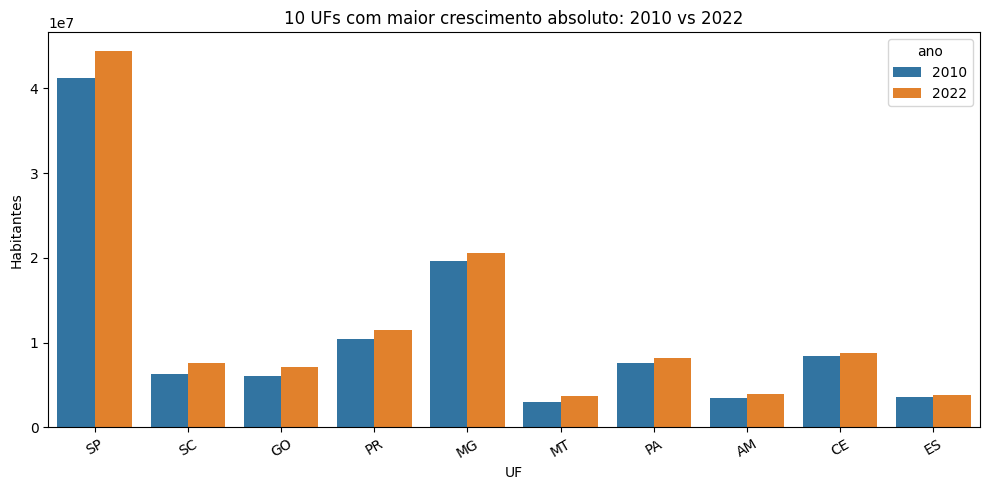

In [9]:
top = pop_estado.head(10).melt(
    id_vars="uf",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
top["ano"] = top["ano"].str.replace("populacao_", "")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="uf", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
ax.set_xlabel("UF")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

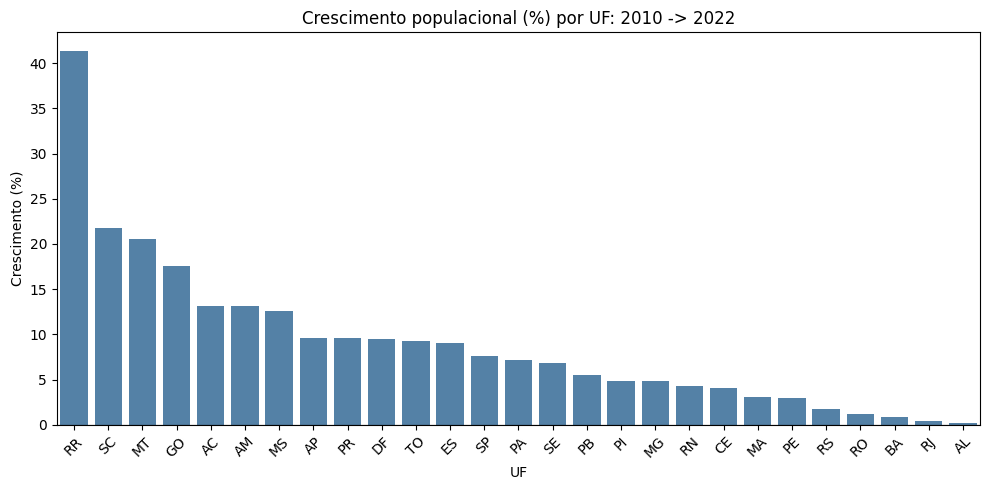

In [10]:
pop_estado_pct = pop_estado.sort_values("crescimento_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pop_estado_pct, x="uf", y="crescimento_pct", ax=ax, color="steelblue")
ax.set_title("Crescimento populacional (%) por UF: 2010 -> 2022")
ax.set_ylabel("Crescimento (%)")
ax.set_xlabel("UF")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()